In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import contextily as cx

import os
from pathlib import Path
import pykrige as pk

In [3]:
data_path = Path(os.environ["DATA_PATH"])

In [18]:
bounds = gpd.read_file(data_path / "lim_aumxl24").to_crs("EPSG:6372")["geometry"].item()

In [30]:
df = gpd.GeoDataFrame(
    pd.read_excel(data_path / "calidad_del_aire.xlsx", sheet_name=1)
    .assign(
        geometry=lambda df: gpd.points_from_xy(df["lng"], df["lat"]),
        date=lambda df: pd.to_datetime(df["Año"].astype(str) + "-" + df["Mes"].astype(str) + "-01", format="%Y-%m-%d"),
    )
    .rename(columns={"µg/m³": "mug/m3"})
    .drop(columns=["lng", "lat", "Año", "Mes"]),
    crs="EPSG:4326",
    geometry="geometry"
).to_crs("EPSG:6372")

df = df[df.within(bounds)]

In [31]:
df

,idmonitor,mug/m3,color,desc,geometry,date
0,SPABC12,0,#00e400,Abajo del límite,POINT (1230819.726 2344590.061),2018-01-01
1,SPABC14,47,#ff8484,Arriba del límite,POINT (1225130.413 2345918.279),2018-01-01
2,SPABC12,0,#00e400,Abajo del límite,POINT (1230819.726 2344590.061),2018-02-01
3,SPABC14,32,#00e400,Abajo del límite,POINT (1225130.413 2345918.279),2018-02-01
4,SPABC12,0,#00e400,Abajo del límite,POINT (1230819.726 2344590.061),2018-03-01
...,...,...,...,...,...,...
2887,pa52101,8,#00e400,Abajo del límite,POINT (1238224.478 2338557.334),2025-07-01
2888,pa91135,18,#00e400,Abajo del límite,POINT (1232850.515 2348662.665),2025-07-01
2889,pa91305,45,#ff8484,Arriba del límite,POINT (1224125.262 2343848.885),2025-07-01
2890,pa91321,29,#00e400,Abajo del límite,POINT (1230907.689 2338589.509),2025-07-01


In [27]:
year = 2025
temp = gpd.GeoDataFrame(
    df
    .query(f"'{year - 1}-12-31' < date < '{year + 1}-01-01'")
    .groupby("idmonitor")
    .agg({
        "geometry": "first",
        "mug/m3": "mean"
    })
)

xmin, ymin, xmax, ymax = temp.total_bounds
xrange = np.arange(xmin, xmax, 100)
yrange = np.arange(ymin, ymax, 100)

model = pk.ok.OrdinaryKriging(
    temp["geometry"].x,
    temp["geometry"].y,
    temp["mug/m3"],
    # variogram_model="linear",
)

z, ss = model.execute("grid", xrange, yrange)

In [29]:
df

,idmonitor,mug/m3,color,desc,geometry,date
0,SPABC12,0,#00e400,Abajo del límite,POINT (1230819.726 2344590.061),2018-01-01
1,SPABC14,47,#ff8484,Arriba del límite,POINT (1225130.413 2345918.279),2018-01-01
2,SPABC12,0,#00e400,Abajo del límite,POINT (1230819.726 2344590.061),2018-02-01
3,SPABC14,32,#00e400,Abajo del límite,POINT (1225130.413 2345918.279),2018-02-01
4,SPABC12,0,#00e400,Abajo del límite,POINT (1230819.726 2344590.061),2018-03-01
...,...,...,...,...,...,...
2887,pa52101,8,#00e400,Abajo del límite,POINT (1238224.478 2338557.334),2025-07-01
2888,pa91135,18,#00e400,Abajo del límite,POINT (1232850.515 2348662.665),2025-07-01
2889,pa91305,45,#ff8484,Arriba del límite,POINT (1224125.262 2343848.885),2025-07-01
2890,pa91321,29,#00e400,Abajo del límite,POINT (1230907.689 2338589.509),2025-07-01


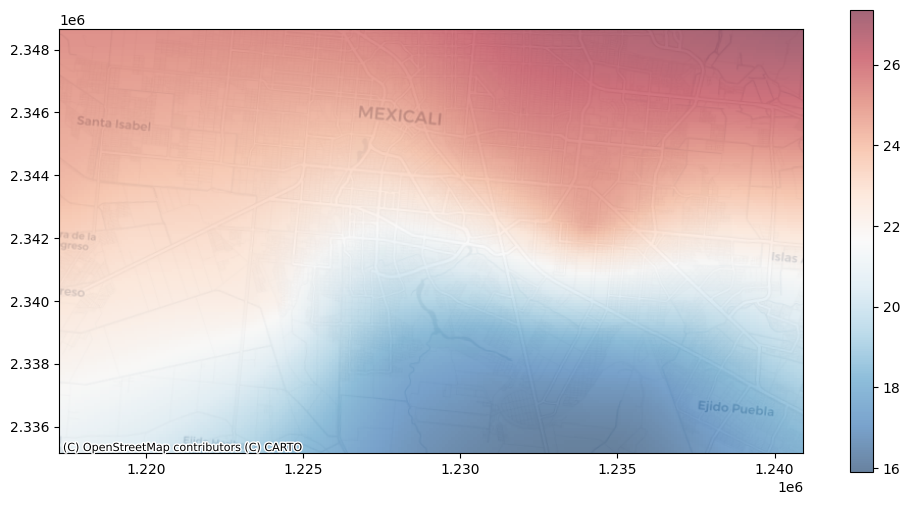

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(z, alpha=0.8, extent=(xmin, xmax, ymin, ymax))
cx.add_basemap(ax, crs=df.crs, source=cx.providers.CartoDB.Positron)
g = ax.imshow(z, alpha=0.6, extent=(xmin, xmax, ymin, ymax), cmap="RdBu_r")
fig.colorbar(g)